<a href="https://colab.research.google.com/github/b2nul/ai-resume-dashboard/blob/main/AI_Resume_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

Load AI-Driven Resume Screening Dataset.

 Resume dataset could give us insight about what qualification are most likely to get you hired. It also help us understand the criteria for AI screening tools to accept or reject an applicants.


> This dataset shows Aplicants's resumes details such as, education Level, job role, no. of projects, experience, and skills. It also illustrate the recutier decision(hired/rejected) and the  AI-based resume ranking score.




In [3]:
df=pd.read_csv("AI_Resume_Screening.csv")
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


# Dataset Overview



In [ ]:
'''no need to change any data types'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
'''From the first sight it seeems like there is no outliers'''
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [ ]:
'''No need to fill certifications column (could be null)'''
df.isna().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [ ]:
'''Certifications missing value percentage'''
df["Certifications"].isna().mean()*100

np.float64(27.400000000000002)

In [ ]:
'''no duplicate'''
df.duplicated().sum()

np.int64(0)

# Check for outliers

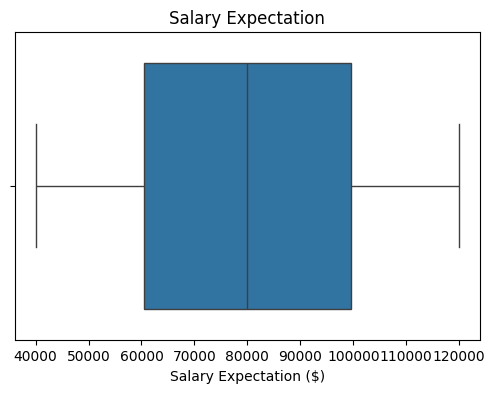

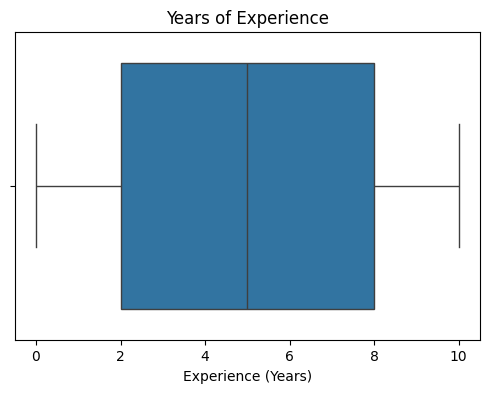

'There are no outliers'

In [ ]:
#Boxplot


plt.figure(figsize=(6,4))
sns.boxplot(x=df["Salary Expectation ($)"])
plt.title("Salary Expectation")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Experience (Years)"])
plt.title("Years of Experience")
plt.show()

'''There are no outliers'''

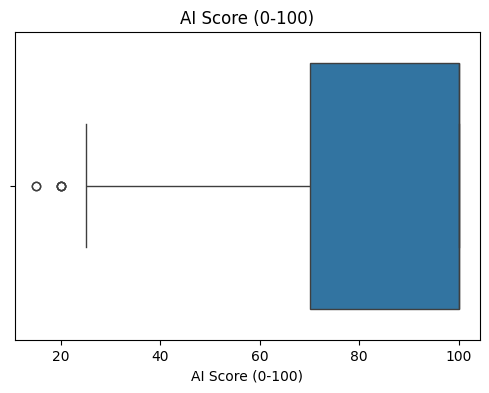

'most AI score were 70 and above and there are 2 outliers under 20'

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["AI Score (0-100)"])
plt.title("AI Score (0-100)")
plt.show()
'''most AI score were 70 and above and there are 2 outliers under 20'''

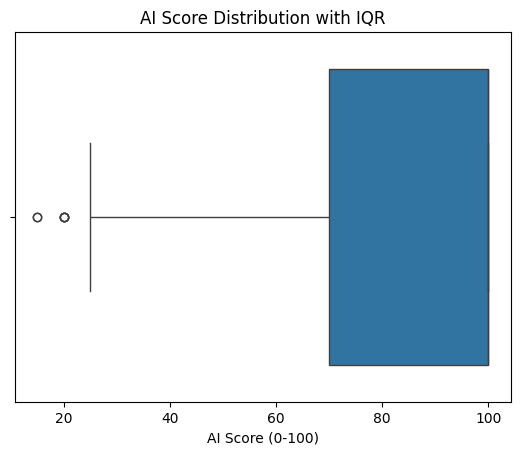

(6, 14)

In [ ]:
Q1 = df["AI Score (0-100)"].quantile(0.25)
Q3 = df["AI Score (0-100)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["AI Score (0-100)"] < lower_bound) |
              (df["AI Score (0-100)"] > upper_bound)]


sns.boxplot(x=df["AI Score (0-100)"])
plt.title("AI Score Distribution with IQR")
plt.show()

outliers.shape

# Exploratory Visualizations:
Class & Data Distribution

## Univariate Analysis

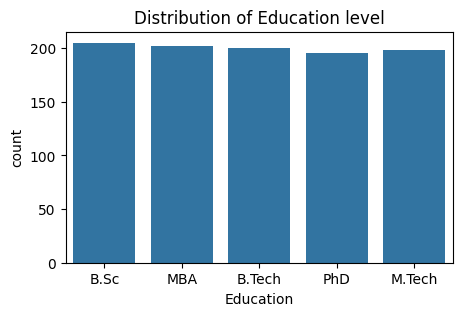

'Education levels are normally distributed'

In [ ]:
# Education
df["Education"].unique()
plt.figure(figsize=(5,3))
sns.countplot(x="Education", data=df)
plt.title("Distribution of Education level")
plt.show()

'''Education levels are normally distributed'''

0.021784894211725588


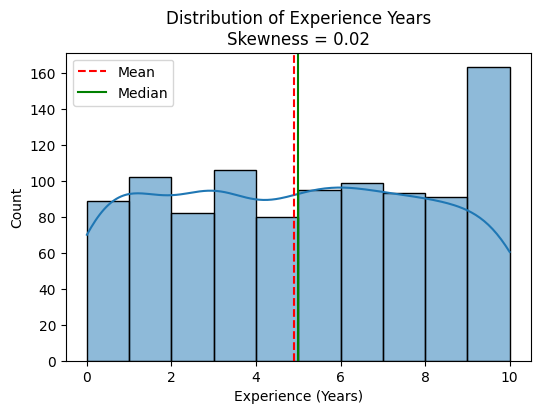

'even though the 10-year bin has a higher count, the overall distribution across 0–10 is same balanced.'

In [ ]:
# Distribution of Experience (Years)
mean_experience = df["Experience (Years)"].mean()
median_experience = df["Experience (Years)"].median()
skew = df["Experience (Years)"].skew()

plt.figure(figsize=(6,4))
sns.histplot(df["Experience (Years)"], bins=10,kde=True)

plt.axvline(mean_experience, color="red", linestyle="--", label="Mean")
plt.axvline(median_experience, color="green", label="Median")
plt.title(f"Distribution of Experience Years\nSkewness = {skew:.2f}")
print(skew)
plt.legend()
plt.show()
'''skew is too little 0.02, The distribution is very close to normal'''
'''even though the 10-year bin has a higher count, the overall distribution across 0–10 is same balanced.'''

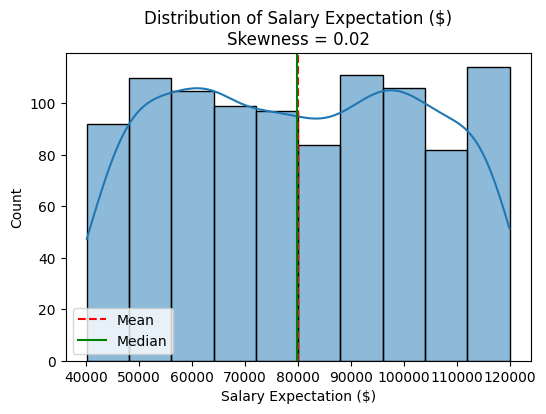

In [ ]:
# Distribution of Experience (Years)
mean_salary = df["Salary Expectation ($)"].mean()
median_salary = df["Salary Expectation ($)"].median()
skew_salary = df["Salary Expectation ($)"].skew()

plt.figure(figsize=(6,4))
sns.histplot(df["Salary Expectation ($)"], bins=10,kde=True)

plt.axvline(mean_salary, color="red", linestyle="--", label="Mean")
plt.axvline(median_salary, color="green", label="Median")
plt.title(f"Distribution of Salary Expectation ($)\nSkewness = {skew_salary:.2f}")

plt.legend()
plt.show()

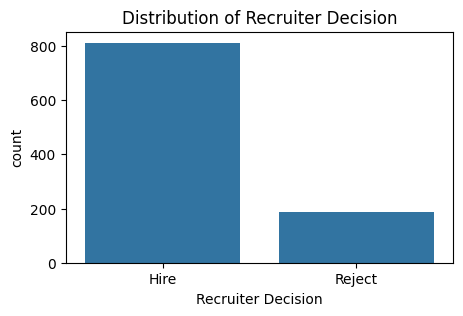

'Recruiter Decision class is imbalanced, with  80% Hire and 20% Reject. This imbalance may bias classification models toward predicting the majority class.'

In [ ]:
#Recruiter Decision
plt.figure(figsize=(5,3))
sns.countplot(x="Recruiter Decision", data=df)
plt.title("Distribution of Recruiter Decision")
plt.show()

'''The plot show that the hiring decisions are three-quarters of the total value represented by reject decision'''
'''Recruiter Decision class is imbalanced, with  80% Hire and 20% Reject. This imbalance may bias classification models toward predicting the majority class.'''

# Bivariante Analysis

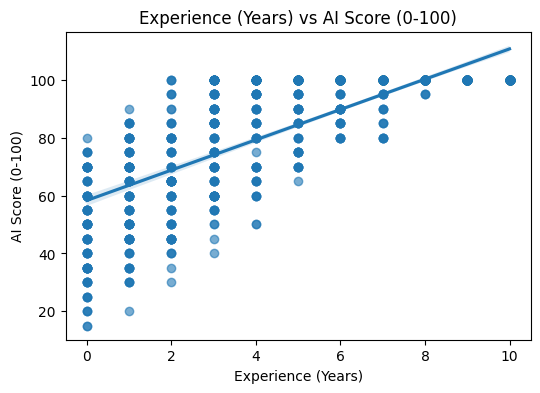

'Aplicant with higher experience tend to receive higher AI scores.\nThe correlation value (0.77) indicates a strong positive relationship. AI model heavily depends on experience.'

In [ ]:
#Experience (Years) vs AI Score (0-100)
plt.figure(figsize=(6,4))
sns.regplot(data=df, x='Experience (Years)', y='AI Score (0-100)', scatter_kws={'alpha':0.6})

plt.title("Experience (Years) vs AI Score (0-100)")
plt.show()

'''Aplicant with higher experience tend to receive higher AI scores.
The correlation value (0.77) indicates a strong positive relationship. AI model heavily depends on experience.'''

'Salary expectation slightly increases with experience, though the correlation is weak (~0.03),\n indicating other factors influence salary expectations.'

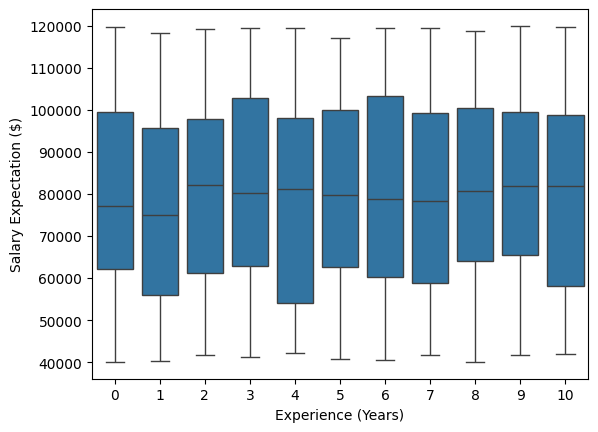

In [ ]:
#Experience (Years) vs Salary Expectation ($)
sns.boxplot(x="Experience (Years)", y="Salary Expectation ($)", data=df)

'''Salary expectation slightly increases with experience, though the correlation is weak (~0.03),
 indicating other factors influence salary expectations.'''

<Axes: xlabel='Recruiter Decision', ylabel='AI Score (0-100)'>

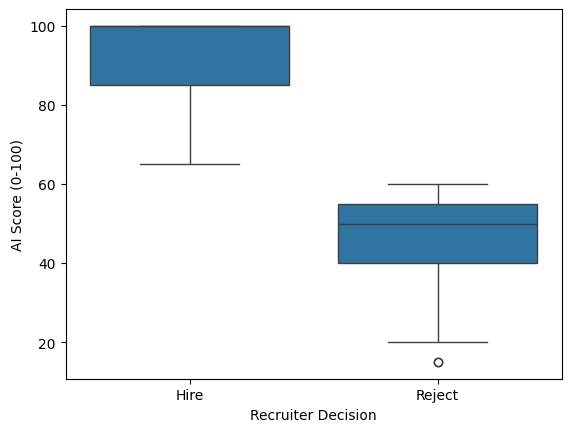

In [ ]:
#Recruiter Decision vs AI Score (0-100)
sns.boxplot(x="Recruiter Decision", y="AI Score (0-100)", data=df)
'''
Candidates with higher AI scores are much more likely to be hired. The median AI score for hired candidates is
significantly higher than for rejected ones, and rejected candidates show more variability,
including some very low scores. This suggests the AI score is strongly associated with the recruiter’s decision.
'''

# Multivariate analysis

In [6]:
df = df.drop(columns=["Resume_ID"]) #not needed
numeric_df = df.select_dtypes(include=[np.number])
#Covariance Matrix
print("Covariance Matrix\n")
numeric_df.cov()

Covariance Matrix



,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
Experience (Years),9.688873,2.497653e+03,-0.669838,50.751552
Salary Expectation ($),2497.653197,5.312321e+08,1620.594957,16130.986286
Projects Count,-0.669838,1.620595e+03,10.441753,24.318969
AI Score (0-100),50.751552,1.613099e+04,24.318969,440.287788


In [7]:
#Correlation Matrix
'''#The correlation between Experience and Projects Count is (-0.066), indicating almost no linear relationship between the two variables.
#this suggests that the number of projects completed by a candidate is largely independent of their years of experience '''

print("Correlation Matrix")
numeric_df.corr()


Correlation Matrix


,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
Experience (Years),1.000000,0.034814,-0.066596,0.777042
Salary Expectation ($),0.034814,1.000000,0.021759,0.033354
Projects Count,-0.066596,0.021759,1.000000,0.358666
AI Score (0-100),0.777042,0.033354,0.358666,1.000000


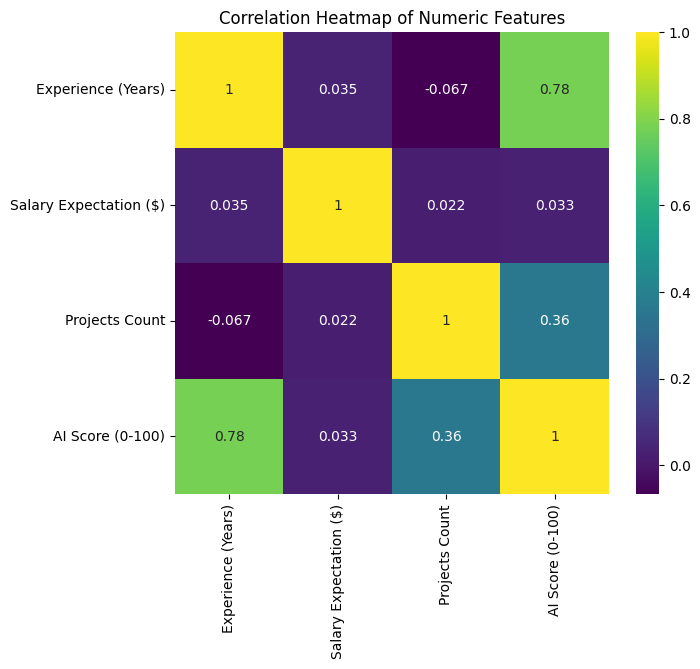

In [8]:
'''coralation heatmap shows that Experience (Years) and AI Scores '''

numeric_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Feature Engineering

Encoding

In [5]:
#One hot encoding
df['Recruiter Decision Encoded'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
df.head()
#df.drop(columns=['Recruiter Decision Binary'], inplace=True)


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Skills_list,Recruiter Decision Encoded
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100,"[TensorFlow, NLP, Pytorch]",1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,"[Deep Learning, Machine Learning, Python, SQL]",1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,"[Ethical Hacking, Cybersecurity, Linux]",1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,"[Python, Pytorch, TensorFlow]",1
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100,"[SQL, React, Java]",1


<Axes: xlabel='AI Class', ylabel='count'>

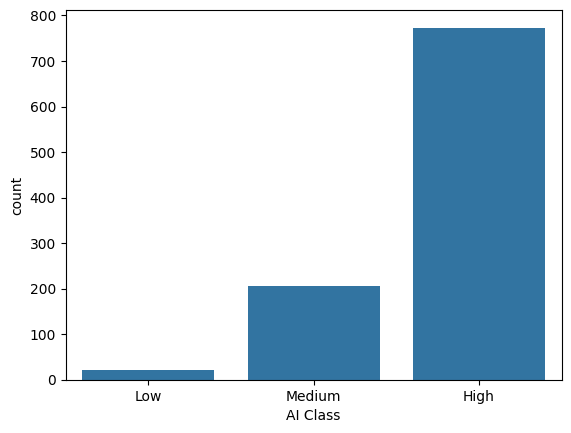

In [11]:
#new feature
df["AI Class"] = pd.cut(
    df["AI Score (0-100)"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

sns.countplot(x="AI Class", data=df)

<Axes: xlabel='Experience Level', ylabel='count'>

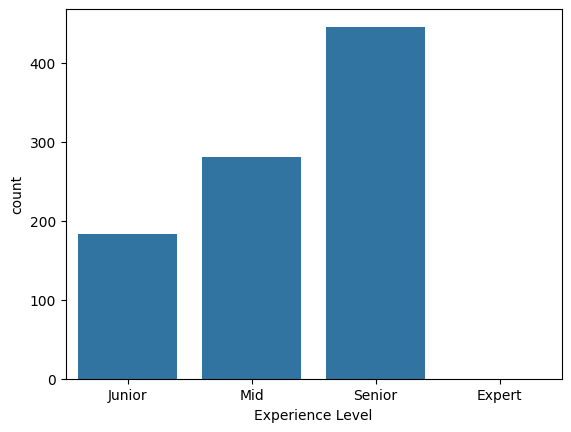

In [ ]:
#new feature
df['Experience Level'] = pd.cut(df['Experience (Years)'],
                                bins=[0, 2, 5, 10, 25],
                                labels=['Junior','Mid','Senior','Expert'])


sns.countplot(x="Experience Level", data=df)

In [23]:
df.head()

,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter Decision Encoded,AI Class,Cert Count
0,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100,1,High,0
1,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1,High,1
2,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1,High,1
3,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1,High,1
4,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100,1,High,0


# Questions and insights

### Q1: Are there candidates with high AI scores who were rejected by HR?

In [12]:
print("Number of aplicants with high AI score who git rejected: ",len(df[(df["AI Class"] == "High") & (df["Recruiter Decision"] == "Reject")]))
'''No one with AI score high got rejected'''

Number of aplicants with high AI score who git rejected:  0


'No one with AI score high got rejected'

In [ ]:
'''There are some AI score= miduim got hired'''
pd.crosstab(df["AI Class"], df["Recruiter Decision"])

Recruiter Decision,Hire,Reject
AI Class,,
Low,0,21
Medium,39,167
High,773,0


/tmp/ipykernel_414/1065596256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("AI Class")["Recruiter Decision"].value_counts(normalize=True).unstack(fill_value=0) * 100


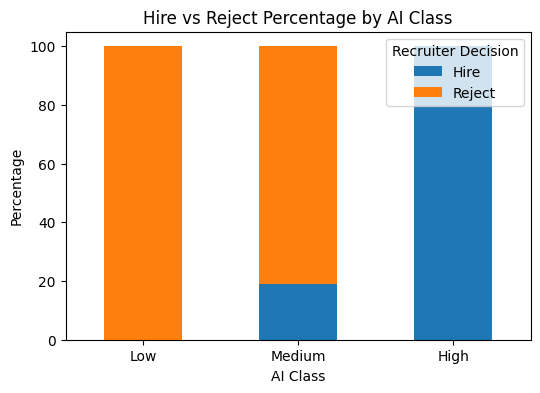

' All candidate with high AI score got hired, and only 20% of the midium class got hired '

In [ ]:
summary = df.groupby("AI Class")["Recruiter Decision"].value_counts(normalize=True).unstack(fill_value=0) * 100
summary.rename(columns={0:'Reject %', 1:'Hire %'}, inplace=True)
summary.plot(kind='bar', stacked=True, figsize=(6,4))
plt.ylabel("Percentage")
plt.title("Hire vs Reject Percentage by AI Class")
plt.xticks(rotation=0)
plt.show()
''' All candidate with high AI score got hired, and only 20% of the midium class got hired '''

1.1 what is the least AI score that got hired ?





In [ ]:
medium_hired = df[
    (df["AI Class"] == "Medium") &
    (df["Recruiter Decision"] == "Hire")
]
print("Count of medium AI score who gets hired: ",len(medium_hired), "out of ", len(df[df["AI Class"] == "Medium"] ))
medium_hired.head()

'''Least AI score who got hired: 65'''

Count of medium AI score who gets hired:  39 out of  206


'Least AI score who got hired: 65'

## Q2- What is the most hired job role?

In [ ]:
'''Most  aplicants were AI researchers and the least were Software Engineer'''
df.groupby("Job Role")["Recruiter Decision"].count()

,Recruiter Decision
Job Role,
AI Researcher,257
Cybersecurity Analyst,255
Data Scientist,255
Software Engineer,233


In [ ]:
 #The table shows the number of applicants hired for each Job Role
hired_per_role = df.groupby("Job Role")["Recruiter Decision Encoded"].sum().sort_values(ascending=False)
print(hired_per_role)


Job Role
AI Researcher            210
Data Scientist           205
Cybersecurity Analyst    202
Software Engineer        195
Name: Recruiter Decision Encoded, dtype: int64


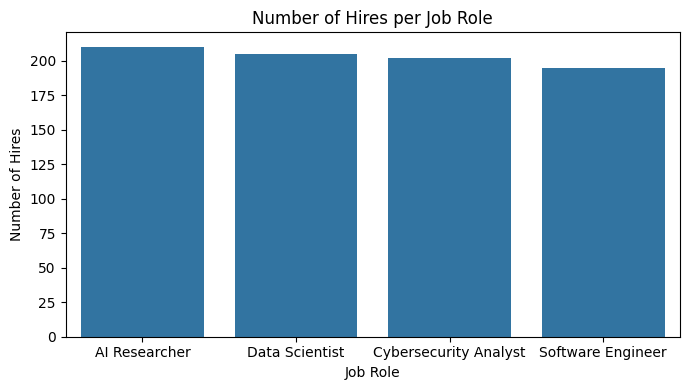

In [ ]:
#The Job Role are AI Researcher was the most hired role
plt.figure(figsize=(7,4))
sns.barplot(x=hired_per_role.index, y=hired_per_role.values)
plt.ylabel("Number of Hires")
plt.xlabel("Job Role")
plt.title("Number of Hires per Job Role")
plt.tight_layout()
plt.show()

In [21]:
# Percentage
hire_per_role = (df.groupby("Job Role")["Recruiter Decision Encoded"]
                 .mean() * 100)
hire_per_role = hire_per_role.sort_values(ascending=False)
hire_per_role_df = hire_per_role.reset_index(name='Hire Percentage (%)')


print(hire_per_role_df)

                Job Role  Hire Percentage (%)
0      Software Engineer            83.690987
1          AI Researcher            81.712062
2         Data Scientist            80.392157
3  Cybersecurity Analyst            79.215686


## Q3. What are the most common skills that influnce hiring?

In [ ]:
#Top 10 skills
hired = df[df["Recruiter Decision"] == "Hire"]
skills = hired["Skills"].str.split(",").explode()
top_skills = skills.value_counts()

print("All skills",df["Skills"].str.split(",").explode().str.strip().unique())
print("\nTop 10 skills",top_skills.head(10))

All skills ['TensorFlow' 'NLP' 'Pytorch' 'Deep Learning' 'Machine Learning' 'Python'
 'SQL' 'Ethical Hacking' 'Cybersecurity' 'Linux' 'React' 'Java'
 'Networking' 'C++']

Top 10 skills Skills
 Python              214
 SQL                 199
 NLP                 120
 Ethical Hacking     115
 Linux               112
 Machine Learning    112
 TensorFlow          110
SQL                  106
 Deep Learning       104
 Java                104
Name: count, dtype: int64


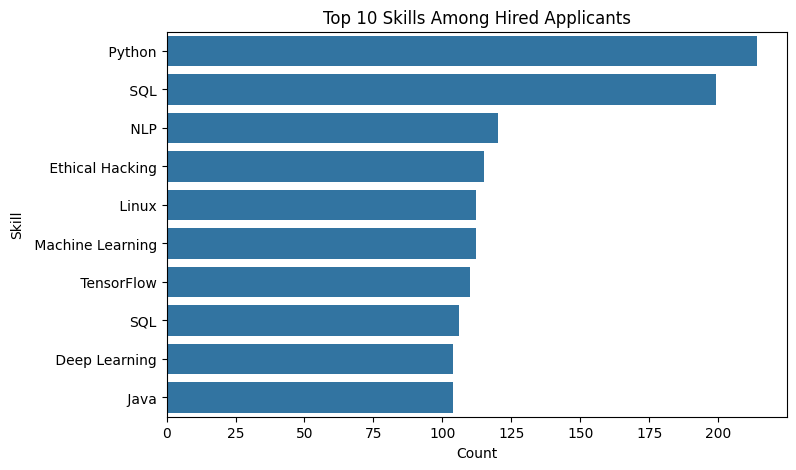

In [ ]:
top10 = top_skills.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Skills Among Hired Applicants")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

In [ ]:
'''Check percentage of hired applicant that have python skill'''
df["Skills"].str.contains("Python", case=False).sum()

python_pct = df["Skills"].str.contains("Python", case=False).mean() * 100
print(f"{python_pct:.2f}% of applicants have Python skill")

38.80% of applicants have Python skill


##Q4. Is there common certificate the accepted applicants have?


Certifications
Deep Learning Specialization    211
AWS Certified                   203
Google ML                       186
Name: count, dtype: int64


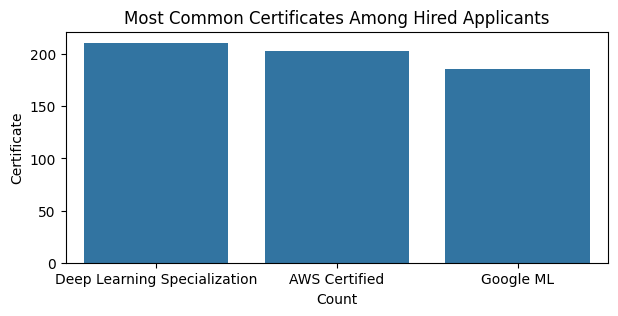

In [ ]:
hired = df[df["Recruiter Decision"] == "Hire"]
certs = hired["Certifications"].str.split(",").explode().str.strip()
top_certs = certs.value_counts()

top10 = top_certs.head(10)
print(top10)
plt.figure(figsize=(7,3))
sns.barplot(y=top10.values, x=top10.index)
plt.title("Most Common Certificates Among Hired Applicants")
plt.xlabel("Count")
plt.ylabel("Certificate")
plt.show()

4.1 Did number of cerificates influnce hiring?

In [14]:
#new feature
df["Cert Count"] = df["Certifications"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(","))) #filled null values with ""
df.groupby("Recruiter Decision")["Cert Count"].mean()

cert_count = df.groupby("Recruiter Decision")["Cert Count"].count()



In [15]:
df[df["Cert Count"] == 0]["Recruiter Decision"].value_counts()
pd.crosstab(df["Cert Count"], df["Recruiter Decision"])

Recruiter Decision,Hire,Reject
Cert Count,,
0,212,62
1,600,126


In [16]:
'''Applicants with at least one certification have a slightly higher hiring rate 82.6% compared to those with no certifications 77.4%
large number of applicants without certifications were still hired, indicating that certifications are not the primary factor in hiring decisions.'''

pd.crosstab(df["Cert Count"], df["Recruiter Decision"], normalize="index")

Recruiter Decision,Hire,Reject
Cert Count,,
0,0.773723,0.226277
1,0.826446,0.173554


## Q5. What influnuced the hiring most education level or years of experinc?

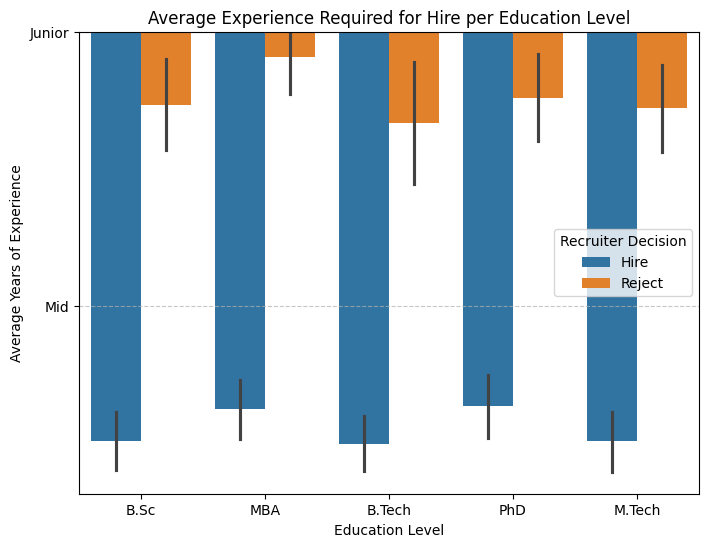

'Hired candidates consistently have more experience than rejected ones\nAcross all education levels. '

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x=df['Education'], y=df['Experience Level'], hue=df['Recruiter Decision'])

plt.title('Average Experience Required for Hire per Education Level')
plt.ylabel('Average Years of Experience')
plt.xlabel('Education Level')
plt.legend(title='Recruiter Decision')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
'''Hired candidates consistently have more experience than rejected ones
Across all education levels. '''

# AI Resume Screening insights:

All candidate with high AI scores got hired, meaning AI score feature have the haighest influunce in Recruiter Decision. The least AI scored applicant who got accepted is 65 score. Hired candidates consistently have more experience than rejected ones across all education levels. On the hand, Job Role feature, Software Engineer have the haighest hireing percent with 83.69098%, while other job roles show similar percentages. The skills that influnce hiring and most hired applicants have are Python,SQL, and NLP. However, when looking at certificate Applicants with at least one certification have a slightly higher hiring rate 82.6% compared to those with no certifications 77.4% large number of applicants without certifications were still hired, indicating that certifications are not the primary factor in hiring decisions.

AI model "not completed yet"

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer, OrdinalEncoder

# clean and split Skills

df['Skills_list'] = df['Skills'].fillna("").str.split(',').apply(lambda x: [i.strip() for i in x if i])

# 2. MultiLabelBinarizer for Skills
# This creates one column per unique skill (One-Hot Encoding for lists)
mlb = MultiLabelBinarizer()
skills_encoded = pd.DataFrame(
    mlb.fit_transform(df['Skills_list']),
    columns=[f"Skill_{s}" for s in mlb.classes_],
    index=df.index
)


# map specific degrees to their general category rank
edu_map = {
    "B.Sc": "Bachelor",
    "B.Tech": "Bachelor",
    "Bachelor": "Bachelor",
    "M.Tech": "Master",
    "MBA": "Master",
    "Master": "Master",
    "PhD": "PhD",
    "High School": "High School"
}

# Standardize the column using the map
df["Education_Cleaned"] = df["Education"].map(edu_map).fillna("Bachelor")

edu_order = ["High School", "Bachelor", "Master", "PhD"]
encoder = OrdinalEncoder(categories=[edu_order])

df["Education_Level_Encoded"] = encoder.fit_transform(df[["Education_Cleaned"]])

df = pd.concat([df, skills_encoded], axis=1)

# drop non numeric and intermediate columns so the model only sees numbers
cols_to_drop = ['Name', 'Skills', 'Skills_list', 'Education', 'Education_Cleaned',
                'Certifications', 'Job Role', 'Recruiter Decision']

x_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Final shape for ML:", x_final.shape)
print(x_final.head())

Final shape for ML: (1000, 21)
   Resume_ID  Experience (Years)  Salary Expectation ($)  Projects Count  \
0          1                  10                  104895               8   
1          2                  10                  113002               1   
2          3                   1                   71766               7   
3          4                   7                   46848               0   
4          5                   4                   87441               9   

   AI Score (0-100)  Recruiter Decision Encoded  Education_Level_Encoded  \
0               100                           1                      1.0   
1               100                           1                      2.0   
2                70                           1                      2.0   
3                95                           1                      1.0   
4               100                           1                      3.0   

   Skill_C++  Skill_Cybersecurity  Skill_Deep Learning 

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Target (y) and Features (X)
y = df['Recruiter Decision Encoded']
X = x_final.drop(columns=['Recruiter Decision Encoded'])
            #leakage
dropped = ['AI Score (0-100)', 'AI Class', 'Resume_ID', 'Name', 'Salary Expectation ($)']

X = x_final.drop(columns=['Recruiter Decision Encoded'] + [c for c in dropped if c in x_final.columns])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

''' Precision 0.93, Recall 0.91 are slightly lower than Class 1 ue to Class Imbalance (hire/reject)'''
'''Overall The model achieved a 96% accuracy, correctly predicted the recruiter’s decision for 192 out of 200 applicant
 in the test set.


Accuracy: 96.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       0.97      0.98      0.98       154

    accuracy                           0.96       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.96      0.96      0.96       200

